/tmp/ipykernel_6300/500209607.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  nifty = yf.download('^NSEI', start = '2015-01-01', end = end)
[*********************100%***********************]  1 of 1 completed


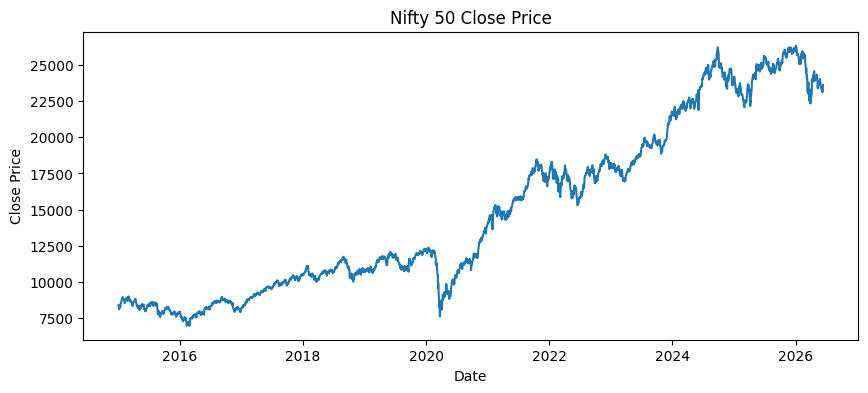

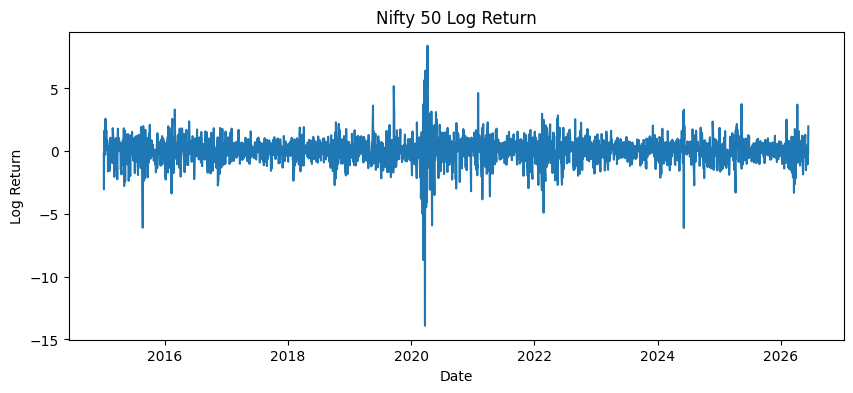

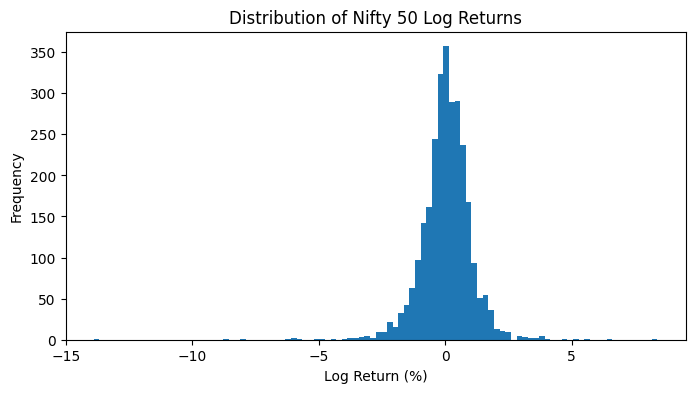

Mean return: 0.03675050377916954
Standard deviation (Volatility): 1.0319801172709826
Kurtosis: 19.591407246787973
Skewness: -1.2999725931291104


In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import date

#nifty data from2 2k15 - 2k26
end = date.today().strftime('%Y-%m-%d')
nifty = yf.download('^NSEI', start = '2015-01-01', end = end)

if isinstance(nifty.columns, pd.MultiIndex):
    nifty.columns = nifty.columns.droplevel(1)

nifty = nifty.dropna()

#plotting
plt.figure(figsize=(10,4)),
plt.plot(nifty.index, nifty['Close'])
plt.title('Nifty 50 Close Price')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.show()

#log return compute
nifty['log_return'] = 100 * np.log(nifty['Close']/nifty['Close'].shift(1))
nfty = nifty.dropna()

#log return plot
plt.figure(figsize=(10,4)),
plt.plot(nfty.index, nfty['log_return'])
plt.title('Nifty 50 Log Return')
plt.xlabel('Date')
plt.ylabel('Log Return')
plt.show()


#histogram plot
plt.figure(figsize=(8,4))
plt.hist(nifty['log_return'], bins=100)
plt.title('Distribution of Nifty 50 Log Returns')
plt.xlabel('Log Return (%)')
plt.ylabel('Frequency')
plt.show()

#stat support
print('Mean return:', nifty['log_return'].mean())
print('Standard deviation (Volatility):', nifty['log_return'].std())
print('Kurtosis:', nifty['log_return'].kurt())
print('Skewness:', nifty['log_return'].skew())